# Fraud Detection in Financial Transactions

This project aims to build a machine learning model to detect fraudulent financial transactions.  
The dataset contains over 6 million transactions with information about transaction type, amount, and account balances.

The objective is to identify patterns associated with fraudulent activities and provide actionable recommendations for fraud prevention.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from sklearn.ensemble import RandomForestClassifier

## Loading the Dataset

The dataset contains financial transaction data including transaction type, transaction amount, sender and receiver balances, and a label indicating whether the transaction is fraudulent.

In [9]:
df = pd.read_csv("fraud.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## Dataset Overview

This step helps us understand the structure of the dataset including:
- number of rows
- number of columns
- data types
- missing values

In [10]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

## Handling Missing Values

Missing values can negatively impact model performance.  
We check for missing values across all columns.

In [11]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

No missing values were found in the dataset, therefore no imputation was required.

## Removing Irrelevant Columns

Columns such as `nameOrig` and `nameDest` represent account identifiers.  
These variables do not contribute meaningful information for predicting fraud and can introduce noise into the model.

In [12]:
df = df.drop(['nameOrig','nameDest'], axis=1)

## Encoding Transaction Type

Machine learning models require numerical input.  
The transaction type column is categorical and therefore needs to be encoded.

In [13]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

## Detecting Outliers

Outliers in transaction amounts may represent suspicious activities or data anomalies.

Boxplots are used to visualize extreme values.

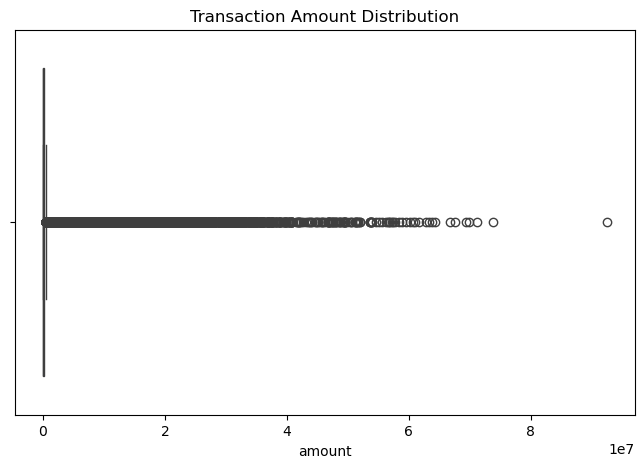

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['amount'])
plt.title("Transaction Amount Distribution")
plt.show()

## Checking Multicollinearity

Highly correlated features can negatively impact model performance.

A correlation matrix is used to identify relationships between variables.

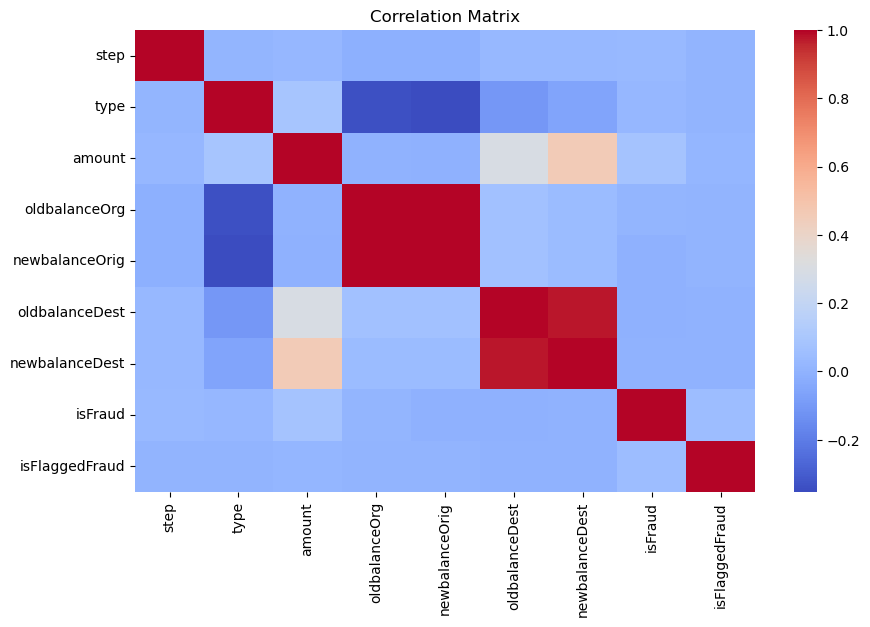

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Fraud Distribution

This step examines the distribution of fraudulent and non-fraudulent transactions.

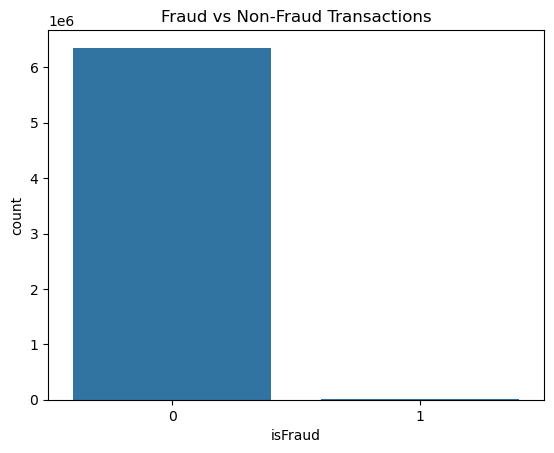

In [16]:
df['isFraud'].value_counts()
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

## Feature Selection

The target variable is `isFraud`.

The remaining variables are used as input features for the machine learning model.

In [17]:
X = df.drop(['isFraud'], axis=1)
y = df['isFraud']

## Splitting Dataset

The dataset is divided into training and testing sets.

Training data is used to build the model while testing data evaluates model performance.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Fraud Detection Model

A Random Forest Classifier is used for fraud detection.

Random Forest is chosen because:
- it handles large datasets efficiently
- it captures nonlinear relationships
- it performs well on classification problems

In [19]:
model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

## Making Predictions

In [20]:
y_pred = model.predict(X_test)

## Model Evaluation

Several metrics are used to evaluate model performance:

- Confusion Matrix
- Precision
- Recall
- F1 Score
- ROC AUC Score

In [23]:
confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))
roc_auc_score(y_test, y_pred)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.98      0.79      0.88      1620

    accuracy                           1.00   1272524
   macro avg       0.99      0.90      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

Model Accuracy: 0.9997155259940087


## Identifying Key Fraud Indicators

Feature importance helps determine which variables contribute most to fraud prediction.

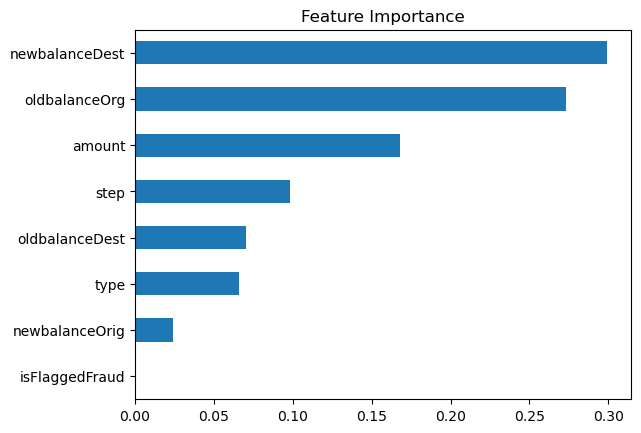

In [24]:
importance = model.feature_importances_

features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

The most important predictors of fraudulent transactions include:

• Transaction amount  
• Transaction type  
• Sender balance before transaction  
• Sender balance after transaction  
• Receiver balance changes  

These variables capture abnormal financial behavior patterns.

Yes, these factors align with real-world fraud behavior.

Fraudulent transactions often involve:
- unusually large transaction amounts
- sudden depletion of account balances
- rapid transfers between accounts

These characteristics are captured by the selected features, validating the model's predictions.

Financial institutions can implement the following prevention measures:

1. Real-time transaction monitoring using machine learning models
2. Multi-factor authentication for high-risk transactions
3. Transaction amount limits
4. Behavioral analysis of account activity
5. Automatic blocking of suspicious accounts

The effectiveness of fraud prevention measures can be evaluated using:

• Reduction in financial losses  
• Fraud detection rate  
• False positive rate  
• Monitoring dashboards for suspicious activity  

Continuous monitoring ensures that the fraud detection system remains effective over time.

This project developed a machine learning model to detect fraudulent financial transactions.

The Random Forest model successfully identified key fraud indicators such as transaction amount and account balance changes.

The insights from this model can help financial institutions implement proactive fraud prevention strategies and improve transaction security.